Title: Reproduction of Spatial Accessibility of COVID-19 Healthcare Resources in Illinois
---

**Reproduction of**: Rapidly measuring spatial accessibility of COVID-19 healthcare resources: a case study of Illinois, USA

Original study *by* Kang, J. Y., A. Michels, F. Lyu, Shaohua Wang, N. Agbodo, V. L. Freeman, and Shaowen Wang. 2020. Rapidly measuring spatial accessibility of COVID-19 healthcare resources: a case study of Illinois, USA. International Journal of Health Geographics 19 (1):1–17. DOI:[10.1186/s12942-020-00229-x](https://ij-healthgeographics.biomedcentral.com/articles/10.1186/s12942-020-00229-x).

Reproduction Authors: Joe Holler, Derrick Burt, and Kufre Udoh
With contributions from Peter Kedron, Drew An-Pham, and the Spring 2021 Open Source GIScience class at Middlebury

Reproduction Materials Available at: [github.com/HEGSRR/RPr-Kang-2020](https://github.com/HEGSRR/RPr-Kang-2020)

Created: `2021-06-01`
Revised: `2021-08-19`

### Original Data
To perform the ESFCA method, three types of data are required, as follows: (1) road network, (2) population, and (3) hospital information. The road network can be obtained from the [OpenStreetMap Python Library, called OSMNX](https://github.com/gboeing/osmnx). The population data is available on the [American Community Survey](https://data.census.gov/cedsci/deeplinks?url=https%3A%2F%2Ffactfinder.census.gov%2F&tid=GOVSTIMESERIES.CG00ORG01). Lastly, hospital information is also publically available on the [Homelanad Infrastructure Foundation-Level Data](https://hifld-geoplatform.opendata.arcgis.com/datasets/hospitals?geometry=-94.504%2C40.632%2C-80.980%2C43.486).

### Modules
Import necessary libraries to run this model.
See `environment.yml` for the library versions used for this analysis.

In [70]:
# Import modules
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import re
from shapely.geometry import Point, LineString, Polygon
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocessing as mp
import folium
import itertools
import os
import time
import warnings
import IPython
import requests
from IPython.display import display, clear_output

warnings.filterwarnings("ignore")
print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

numpy==1.22.0
pandas==1.3.5
geopandas==0.10.2
networkx==2.6.3
osmnx==1.1.2
re==2.2.1
folium==0.12.1.post1
IPython==8.3.0
requests==2.27.1
ipywidgets==7.6.5


## Check Directories

Because we have restructured the repository for replication, we need to check our working directory and make necessary adjustments.

In [71]:
# Check working directory
os.getcwd()

'/home/jovyan/work/RPr-Kang-2020'

In [72]:
# Use to set work directory properly
if os.path.basename(os.getcwd()) == 'code':
    os.chdir('../../')
os.getcwd()

'/home/jovyan/work/RPr-Kang-2020'

## Load and Visualize Data

### Population and COVID-19 Cases Data by County

*'Cases' column is coming in as 'Unnamed_0' --> easy to rename but this probably should be reportede to the original authors*

If you would like to use the data generated from the pre-processing scripts, use the following code:

```py
covid_data = gpd.read_file('./data/raw/public/Pre-Processing/covid_pre-processed.shp')
atrisk_data = gpd.read_file('./data/raw/public/Pre-Processing/atrisk_pre-processed.shp')
```

In [73]:
# Read in at risk population data
atrisk_data = gpd.read_file('./data/raw/public/PopData/Illinois_Tract.shp')
atrisk_data.head()

,GEOID,STATEFP,COUNTYFP,TRACTCE,NAMELSAD,Pop,Unnamed_ 0,NAME,OverFifty,TotalPop,geometry
0,17091011700,17,091,011700,Census Tract 117,3688,588,"Census Tract 117, Kankakee County, Illinois",1135,3688,"POLYGON ((-87.88768 41.13594, -87.88764 41.136..."
1,17091011800,17,091,011800,Census Tract 118,2623,220,"Census Tract 118, Kankakee County, Illinois",950,2623,"POLYGON ((-87.89410 41.14388, -87.89400 41.143..."
2,17119400951,17,119,400951,Census Tract 4009.51,5005,2285,"Census Tract 4009.51, Madison County, Illinois",2481,5005,"POLYGON ((-90.11192 38.70281, -90.11128 38.703..."
3,17119400952,17,119,400952,Census Tract 4009.52,3014,2299,"Census Tract 4009.52, Madison County, Illinois",1221,3014,"POLYGON ((-90.09442 38.72031, -90.09360 38.720..."
4,17135957500,17,135,957500,Census Tract 9575,2869,1026,"Census Tract 9575, Montgomery County, Illinois",1171,2869,"POLYGON ((-89.70369 39.34803, -89.69928 39.348..."


In [127]:
# Read in covid case data
covid_data = gpd.read_file('./data/raw/public/PopData/Illinois_ZIPCODE.shp')
covid_data['cases'] = covid_data['cases']
covid_data.head()

,ZCTA5CE10,County,State,Join,ZONE,ZONENAME,FIPS,pop,cases,Prop,geometry
0,61820,Champaign County,IL,Champaign County IL,IL_E,Illinois East,1201,38156,0,0.000000,"POLYGON ((653306.788 1927406.929, 653301.836 1..."
1,61821,Champaign County,IL,Champaign County IL,IL_E,Illinois East,1201,30582,10,0.000327,"MULTIPOLYGON (((650592.255 1927477.347, 650514..."
2,61822,Champaign County,IL,Champaign County IL,IL_E,Illinois East,1201,25829,19,0.000736,"MULTIPOLYGON (((655341.261 1922708.054, 655334..."
3,61830,Piatt County,IL,Piatt County IL,IL_E,Illinois East,1201,337,0,0.000000,"POLYGON ((609988.579 1911459.483, 609975.674 1..."
4,61831,Vermilion County,IL,Vermilion County IL,IL_E,Illinois East,1201,134,0,0.000000,"POLYGON ((691601.661 1945543.666, 691609.138 1..."


### Load Hospital Data

Note that 999 is treated as a "NULL"/"NA" so these hospitals are filtered out. This data contains the number of ICU beds and ventilators at each hospital.

In [166]:
# Read in hospital data
hospitals = gpd.read_file('./data/raw/public/HospitalData/Chicago_Hospital_Info.shp')
hospitals.head()

,FID,Hospital,City,ZIP_Code,X,Y,Total_Bed,Adult ICU,Total Vent,geometry
0,2,Methodist Hospital of Chicago,Chicago,60640,-87.671079,41.972800,145,36,12,MULTIPOINT (-87.67108 41.97280)
1,4,Advocate Christ Medical Center,Oak Lawn,60453,-87.732483,41.720281,785,196,64,MULTIPOINT (-87.73248 41.72028)
2,13,Evanston Hospital,Evanston,60201,-87.683288,42.065393,354,89,29,MULTIPOINT (-87.68329 42.06539)
3,24,AMITA Health Adventist Medical Center Hinsdale,Hinsdale,60521,-87.920116,41.805613,261,65,21,MULTIPOINT (-87.92012 41.80561)
4,25,Holy Cross Hospital,Chicago,60629,-87.690841,41.770001,264,66,21,MULTIPOINT (-87.69084 41.77000)


### Generate and Plot Map of Hospitals

In [76]:
# Plot hospital data
m = folium.Map(location=[41.85, -87.65], tiles='cartodbpositron', zoom_start=10)
for i in range(0, len(hospitals)):
    folium.CircleMarker(
      location=[hospitals.iloc[i]['Y'], hospitals.iloc[i]['X']],
      popup="{}{}\n{}{}\n{}{}".format('Hospital Name: ',hospitals.iloc[i]['Hospital'],
                                      'ICU Beds: ',hospitals.iloc[i]['Adult ICU'],
                                      'Ventilators: ', hospitals.iloc[i]['Total Vent']),
      radius=5,
      color='blue',
      fill=True,
      fill_opacity=0.6,
      legend_name = 'Hospitals'
    ).add_to(m)
legend_html =   '''<div style="position: fixed; width: 20%; heigh: auto;
                            bottom: 10px; left: 10px;
                            solid grey; z-index:9999; font-size:14px;
                            ">&nbsp; Legend<br>'''

m

### Load and Plot Hexagon Grids (500-meter resolution)

<AxesSubplot:>

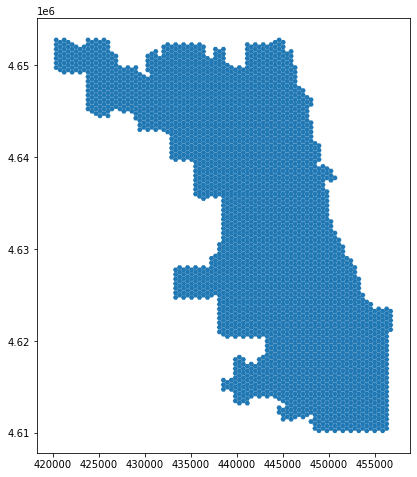

In [77]:
# Read in and plot grid file for Chicago
grid_file = gpd.read_file('./data/raw/public/GridFile/Chicago_Grid.shp')
grid_file.plot(figsize=(8,8))

### Load the Road Network

If `Chicago_Network_Buffer.graphml` does not already exist, this cell will query the road network from OpenStreetMap.  

Each of the road network code blocks may take a few mintues to run.

In [78]:
%%time
# To create a new graph from OpenStreetMap, delete or rename data/raw/private/Chicago_Network_Buffer.graphml 
# (if it exists), and set OSM to True 
OSM = False

# if buffered street network is not saved, and OSM is preferred, # generate a new graph from OpenStreetMap and save it
if not os.path.exists("./data/raw/private/Chicago_Network_Buffer.graphml") and OSM:
    print("Loading buffered Chicago road network from OpenStreetMap. Please wait... runtime may exceed 9min...", flush=True)
    G = ox.graph_from_place('Chicago', network_type='drive', buffer_dist=24140.2) 
    print("Saving Chicago road network to raw/private/Chicago_Network_Buffer.graphml. Please wait...", flush=True)
    ox.save_graphml(G, './data/raw/private/Chicago_Network_Buffer.graphml')
    print("Data saved.")

# otherwise, if buffered street network is not saved, download graph from the OSF project
elif not os.path.exists("./data/raw/private/Chicago_Network_Buffer.graphml"):
    print("Downloading buffered Chicago road network from OSF...", flush=True)
    url = 'https://osf.io/download/z8ery/'
    r = requests.get(url, allow_redirects=True)
    print("Saving buffered Chicago road network to file...", flush=True)
    open('./data/raw/private/Chicago_Network_Buffer.graphml', 'wb').write(r.content)

# if the buffered street network is already saved, load it
if os.path.exists("./data/raw/private/Chicago_Network_Buffer.graphml"):
    print("Loading buffered Chicago road network from raw/private/Chicago_Network_Buffer.graphml. Please wait...", flush=True)
    G = ox.load_graphml('./data/raw/private/Chicago_Network_Buffer.graphml') 
    print("Data loaded.") 
else:
    print("Error: could not load the road network from file.")

Loading buffered Chicago road network from raw/private/Chicago_Network_Buffer.graphml. Please wait...
Data loaded.
CPU times: user 45.2 s, sys: 989 ms, total: 46.1 s
Wall time: 49.1 s


### Plot the Road Network

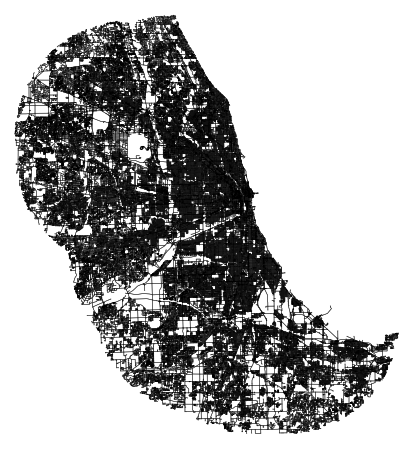

CPU times: user 1min 11s, sys: 682 ms, total: 1min 12s
Wall time: 1min 11s


(<Figure size 576x576 with 1 Axes>, <AxesSubplot:>)

In [10]:
%%time
ox.plot_graph(G, node_size = 1, bgcolor = 'white', node_color = 'black', edge_color = "#333333", node_alpha = 0.5, edge_linewidth = 0.5)

#### Check speed limit values

Display all the unique speed limit values and count how many network edges (road segments) have each value.
We will compare this to our cleaned network later.

In [81]:
%%time
# Turn nodes and edges into geodataframes
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Get unique counts of road segments for each speed limit
print('Total edges: ', len(edges))
print('No speed data: ', edges['maxspeed'].isna().sum())
print(edges['maxspeed'].value_counts())

Total edges:  384240
No speed data:  366175
25 mph                        4793
30 mph                        3555
35 mph                        3364
40 mph                        2093
45 mph                        1418
20 mph                        1155
55 mph                         614
60 mph                         279
50 mph                         191
40                              79
15 mph                          76
70 mph                          71
65 mph                          54
10 mph                          38
[40 mph, 45 mph]                27
[30 mph, 35 mph]                26
45,30                           24
[40 mph, 35 mph]                22
70                              21
25                              20
[55 mph, 45 mph]                16
25, east                        14
[45 mph, 35 mph]                13
[30 mph, 25 mph]                10
[45 mph, 50 mph]                 8
50                               8
[40 mph, 30 mph]                 7
[35 mph, 25

In [82]:
edges.head()

osmid      highway oneway  length  speed_kph  \
u         v         key                                                    
261095436 261095437 0    24067717  residential  False  46.873       39.2   
261095437 261095439 0    24067717  residential  False  46.317       39.2   
          261095436 0    24067717  residential  False  46.873       39.2   
          261109275 0    24069424  residential  False  34.892       39.2   
          261109274 0    24069424  residential  False  47.866       39.2   

                         travel_time name  \
u         v         key                     
261095436 261095437 0            4.3  NaN   
261095437 261095439 0            4.3  NaN   
          261095436 0            4.3  NaN   
          261109275 0            3.2  NaN   
          261109274 0            4.4  NaN   

                                                                  geometry  \
u         v         key                                                      
261095436 261095437 0    LINESTRING (-87.90237 42.10571, -87.90198 42.1...   
261095437 261095439 0    LINESTRING (-87.90198 42.10540, -87.90159 42.1...   
          261095436 0    LINESTRING (-87.90198 42.10540, -87.90237 42.1...   
          261109275 0    LINESTRING (-87.90198 42.10540, -87.90227 42.1...   
          261109274 0    LINESTRING (-87.90198 42.10540, -87.90156 42.1...   

                        lanes  ref bridge maxspeed access service tunnel  \
u         v         key                                                    
261095436 261095437 0     NaN  NaN    NaN      NaN    NaN     NaN    NaN   
261095437 261095439 0     NaN  NaN    NaN      NaN    NaN     NaN    NaN   
          261095436 0     NaN  NaN    NaN      NaN    NaN     NaN    NaN   
          261109275 0     NaN  NaN    NaN      NaN    NaN     NaN    NaN   
          261109274 0     NaN  NaN    NaN      NaN    NaN     NaN    NaN   

                        junction width area  
u         v         key                      
261095436 261095437 0        NaN   NaN  NaN  
261095437 261095439 0        NaN   NaN  NaN  
          261095436 0        NaN   NaN  NaN  
          261109275 0        NaN   NaN  NaN  
          261109274 0        NaN   NaN  NaN

### network_setting function

Cleans the OSMNX network to work better with drive-time analysis.

First, we remove all nodes with 0 outdegree because any hospital assigned to such a node would be unreachable from everywhere. Next, we remove small (under 10 node) *strongly connected components* to reduce erroneously small ego-centric networks. Lastly, we ensure that the max speed is set and in the correct units before calculating time.

Args:

* network: OSMNX network for the spatial extent of interest

Returns:

* OSMNX network: cleaned OSMNX network for the spatial extent

In [83]:
# two things about this function:
# 1) the work to remove nodes is hardly worth it now that OSMnx cleans graphs by default
# the function is now only pruning < 300 nodes
# 2) try using the OSMnx speed module for setting speeds, travel times
# https://osmnx.readthedocs.io/en/stable/user-reference.html#module-osmnx.speed
# just be careful about units of speed and time!
# the remainder of this code expects 'time' to be measured in minutes

def network_setting(network):
    _nodes_removed = len([n for (n, deg) in network.out_degree() if deg ==0])
    network.remove_nodes_from([n for (n, deg) in network.out_degree() if deg ==0])
    for component in list(nx.strongly_connected_components(network)):
        if len(component)<10:
            for node in component:
                _nodes_removed+=1
                network.remove_node(node)
    for u, v, k, data in tqdm(G.edges(data=True, keys=True),position=0):
        if 'maxspeed' in data.keys():
            speed_type = type(data['maxspeed'])
            if (speed_type==str):
                # Add in try/except blocks to catch maxspeed formats that don't fit Kang et al's cases
                try:
                    if len(data['maxspeed'].split(','))==2:
                        data['maxspeed_fix']=float(data['maxspeed'].split(',')[0])                  
                    elif data['maxspeed']=='signals':
                        data['maxspeed_fix']=30.0 # drive speed setting as 35 miles
                    else:
                        data['maxspeed_fix']=float(data['maxspeed'].split()[0])
                except:
                    data['maxspeed_fix']=30.0 #miles
            else:
                try:
                    data['maxspeed_fix']=float(data['maxspeed'][0].split()[0])
                except:
                    data['maxspeed_fix']=30.0 #miles
        else:
            data['maxspeed_fix']=30.0 #miles
        data['maxspeed_meters'] = data['maxspeed_fix']*26.8223 # convert mile per hour to meters per minute
        data['time'] = float(data['length'])/ data['maxspeed_meters'] # meters / meters per minute = minutes
    print("Removed {} nodes ({:2.4f}%) from the OSMNX network".format(_nodes_removed, _nodes_removed/float(network.number_of_nodes())))
    print("Number of nodes: {}".format(network.number_of_nodes()))
    print("Number of edges: {}".format(network.number_of_edges()))    
    return(network)

### Simplify the network and speed data

Simplify road network by removing redundant nodes and edges.
Sythesize OpenStreetMap speed limit data and fill in missing data.

In [180]:
%%time
# set oxSpeed to True to replace network_setting 
oxSpeed = True

# Other weighting options representing different distance decays

if oxSpeed:
    print("Calculating speeds with osmnx...")
    # calculate speed_kph field; maxspeeds with 'mph' will be converted; speeds without units assumed to be kph
    Gs = ox.speed.add_edge_speeds(G)
    print("Calculating travel times with osmnx...")
    # calculate travel_time field with time in seconds
    Gt = ox.speed.add_edge_travel_times(G)
else:
    print("Calculating speed and travel times with network setting function...")
    Gt = network_setting(G)
    distances = [x * 60 for x in distances]

# Create point geometries for each node in the graph, to make constructing catchment area polygons easier
print("Creating point geometries for each node...")
for node, data in Gt.nodes(data=True):
    data['geometry']=Point(data['x'], data['y'])

Calculating speeds with osmnx...
Calculating travel times with osmnx...
Creating point geometries for each node...
CPU times: user 46.2 s, sys: 919 ms, total: 47.1 s
Wall time: 53.6 s


#### Re-check speed limit values

Display all the unique speed limit values and count how many network edges (road segments) have each value.
Compare to the previous results.

In [181]:
%%time
## Get unique counts for each road network
# Turn nodes and edges in geodataframes
nodes, edges = ox.graph_to_gdfs(Gt, nodes=True, edges=True)

# Count
if oxSpeed:
    print(edges['speed_kph'].value_counts())
else:    
    print(edges['maxspeed_fix'].value_counts())
print(str(len(edges)) + " edges in graph")

39.2     291413
48.3      29822
56.7      26353
60.1      14985
40.2       5604
56.3       3364
86.3       2200
64.4       2093
32.2       1872
42.9       1793
72.4       1418
69.8        654
88.5        606
90.1        565
96.6        277
80.5        191
51.0        118
40.0         80
24.1         76
112.7        61
104.6        42
16.1         38
25.0         34
68.0         29
52.0         26
45.3         24
60.0         24
70.0         21
64.0         18
80.0         16
44.0         12
56.0          9
76.0          8
50.0          8
48.0          8
36.0          6
92.0          5
96.0          4
71.0          4
20.0          4
104.0         3
32.0          3
72.0          3
45.0          3
100.0         3
52.4          2
55.0          2
108.0         2
35.0          2
53.0          2
84.0          1
Name: speed_kph, dtype: int64
383911 edges in graph
CPU times: user 39.1 s, sys: 224 ms, total: 39.4 s
Wall time: 45.1 s


### hospital_setting

Finds the nearest network node for each hospital.

In [182]:
nodes_osmid = gpd.GeoDataFrame(nodes[["geometry"]]).reset_index()
# print(nodes_osmid.head())

hospitals = gpd.sjoin_nearest(hospitals, nodes_osmid, distance_col="distances")

#rename column from osmid to nearest_osm, so that it works with other code
hospitals.rename(columns={"osmid": "nearest_osm"}, inplace=True)
hospitals.head()

ValueError: 'index_left' and 'index_right' cannot be names in the frames being joined

### pop_centroid

Converts geodata to centroids

Args:

* pop_data: a GeodataFrame
* pop_type: a string, either "pop" for general population or "covid" for COVID-19 case data

Returns:

* GeoDataFrame of centroids with population data

In [168]:
# this function would be faster with a GeoPandas approach

def pop_centroid (pop_data, pop_type):
    pop_data = pop_data.to_crs({'init': 'epsg:4326'})
    # If pop is selected in dropdown, select at risk pop where population is greater than 0
    if pop_type =="pop":
        pop_data=pop_data[pop_data['OverFifty']>=0]
    # If covid is selected in dropdown, select where covid cases are greater than 0
    if pop_type =="covid":
        pop_data=pop_data[pop_data['cases']>=0]
    pop_cent = pop_data.centroid # it make the polygon to the point without any other information
    # Convert to gdf
    pop_centroid = gpd.GeoDataFrame()
    i = 0
    for point in tqdm(pop_cent, desc='Pop Centroid File Setting', position=0):
        if pop_type== "pop":
            pop = pop_data.iloc[i]['OverFifty']
            code = pop_data.iloc[i]['GEOID']
        if pop_type =="covid":
            pop = pop_data.iloc[i]['cases']
            code = pop_data.iloc[i].ZCTA5CE10
        pop_centroid = pop_centroid.append({'code':code,'pop': pop,'geometry': point}, ignore_index=True)
        i = i+1
    return(pop_centroid)

### djikstra_cca_polygons

Function written by Joe Holler + Derrick Burt. It is a more efficient way to calculate distance-weighted catchment areas for each hospital. The algorithm runs quicker than the original one ("calculate_catchment_area"). It first creates a dictionary (with a node and its corresponding drive time from the hospital) of all nodes within a 30 minute drive time (using single_cource_dijkstra_path_length function). From here, two more dictionaries are constructed by querying the original one. From this dictionaries, single part convex hulls are created for each drive time interval and appended into a single list (one list with 3 polygon geometries). Within the list, the polygons are differenced from each other to produce three catchment areas.

Args:
* G: cleaned network graph *with node point geometries attached*
* nearest_osm: A unique nearest node ID calculated for a single hospital
* distances: 3 distances (in drive time) to calculate catchment areas from
* distance_unit: unit to calculate (time)

Returns:
* A list of 3 diffrenced (not-overlapping) catchment area polygons (10 min poly, 20 min poly, 30 min poly)

In [128]:
def dijkstra_cca_polygons(G, nearest_osm, distances, distance_unit = "time"):
  
    ## CREATE DICTIONARIES
    # create dictionary of nearest nodes
    nearest_nodes_30 = nx.single_source_dijkstra_path_length(G, nearest_osm, distances[2], distance_unit) # creating the largest graph from which 10 and 20 minute drive times can be extracted from
    
    # extract values within 20 and 10 (respectively) minutes drive times
    nearest_nodes_20 = dict()
    nearest_nodes_10 = dict()
    for key, value in nearest_nodes_30.items():
        if value <= 20:
            nearest_nodes_20[key] = value
        if value <= 10:
            nearest_nodes_10[key] = value
    
    ## CREATE POLYGONS FOR 3 DISTANCE CATEGORIES (10 min, 20 min, 30 min)
    # 30 MIN
    # If the graph already has a geometry attribute with point data,
    # this line will create a GeoPandas GeoDataFrame from the nearest_nodes_30 dictionary
    points_30 = gpd.GeoDataFrame(gpd.GeoSeries(nx.get_node_attributes(G.subgraph(nearest_nodes_30), 'geometry')))

    # This line converts the nearest_nodes_30 dictionary into a Pandas data frame and joins it to points
    # left_index=True and right_index=True are options for merge() to join on the index values
    points_30 = points_30.merge(pd.Series(nearest_nodes_30).to_frame(), left_index=True, right_index=True)

    # Re-name the columns and set the geodataframe geometry to the geometry column
    points_30 = points_30.rename(columns={'0_x':'geometry','0_y':'z'}).set_geometry('geometry')

    # Create a convex hull polygon from the points
    polygon_30 = gpd.GeoDataFrame(gpd.GeoSeries(points_30.unary_union.convex_hull))
    polygon_30 = polygon_30.rename(columns={0:'geometry'}).set_geometry('geometry')
    
    # 20 MIN
    # Select nodes less than or equal to 20
    points_20 = points_30.query("z <= 20")
    
    # Create a convex hull polygon from the points
    polygon_20 = gpd.GeoDataFrame(gpd.GeoSeries(points_20.unary_union.convex_hull))
    polygon_20 = polygon_20.rename(columns={0:'geometry'}).set_geometry('geometry')
    
    # 10 MIN
    # Select nodes less than or equal to 10
    points_10 = points_30.query("z <= 10")
    
    # Create a convex hull polygon from the points
    polygon_10 = gpd.GeoDataFrame(gpd.GeoSeries(points_10.unary_union.convex_hull))
    polygon_10 = polygon_10.rename(columns={0:'geometry'}).set_geometry('geometry')
    
    # Create empty list and append polygons
    polygons = []
    
    # Append
    polygons.append(polygon_10)
    polygons.append(polygon_20)
    polygons.append(polygon_30)
    
    # Clip the overlapping distance ploygons (create two donuts + hole)
    for i in reversed(range(1, len(distances))):
        polygons[i] = gpd.overlay(polygons[i], polygons[i-1], how="difference")

    return polygons

### hospital_measure_acc (adjusted to incorporate dijkstra_cca_polygons)

Measures the effect of a single hospital on the surrounding area. (Uses `dijkstra_cca_polygons`)

Args:

* \_thread\_id: int used to keep track of which thread this is
* hospital: Geopandas dataframe with information on a hospital
* pop_data: Geopandas dataframe with population data
* distances: Distances in time to calculate accessibility for
* weights: how to weight the different travel distances

Returns:

* Tuple containing:
    * Int (\_thread\_id)
    * GeoDataFrame of catchment areas with key stats

In [97]:
def hospital_measure_acc (_thread_id, hospital, pop_data, distances, weights):
    # Create polygons
    polygons = dijkstra_cca_polygons(G, hospital['nearest_osm'], distances)
    
    # Calculate accessibility measurements
    num_pops = []
    for j in pop_data.index:
        point = pop_data['geometry'][j]
        # Multiply polygons by weights
        for k in range(len(polygons)):
            if len(polygons[k]) > 0: # To exclude the weirdo (convex hull is not polygon)
                if (point.within(polygons[k].iloc[0]["geometry"])):
                    num_pops.append(pop_data['pop'][j]*weights[k])  
    total_pop = sum(num_pops)
    for i in range(len(distances)):
        polygons[i]['time']=distances[i]
        polygons[i]['total_pop']=total_pop
        polygons[i]['icu_beds'] = float(hospital['Adult ICU'])/polygons[i]['total_pop'] # proportion of # of beds over pops in 10 mins
        polygons[i]['vents'] = float(hospital['Total Vent'])/polygons[i]['total_pop'] # proportion of # of beds over pops in 10 mins
        polygons[i].crs = { 'init' : 'epsg:4326'}
        polygons[i] = polygons[i].to_crs({'init':'epsg:32616'})
    print('{:.0f}'.format(_thread_id), end=" ", flush=True)
    return(_thread_id, [ polygon.copy(deep=True) for polygon in polygons ]) 

### measure_acc_par

Parallel implementation of accessibility measurement.

Args:

* hospitals: Geodataframe of hospitals
* pop_data: Geodataframe containing population data
* network: OSMNX street network
* distances: list of distances to calculate catchments for
* weights: list of floats to apply to different catchments
* num\_proc: number of processors to use.

Returns:

* Geodataframe of catchments with accessibility statistics calculated

In [98]:
def hospital_acc_unpacker(args):
    return hospital_measure_acc(*args)

# WHERE THE RESULTS ARE POOLED AND THEN REAGGREGATED
def measure_acc_par (hospitals, pop_data, network, distances, weights, num_proc = 4):
    catchments = []
    # this makes a geodataframe for each distance band. weird! 
    for distance in distances:
        catchments.append(gpd.GeoDataFrame())
    pool = mp.Pool(processes = num_proc)
    hospital_list = [ hospitals.iloc[i] for i in range(len(hospitals)) ]
    print("Calculating", len(hospital_list), "hospital catchments...\ncompleted number:", end=" ")
    results = pool.map(hospital_acc_unpacker, zip(range(len(hospital_list)), hospital_list, itertools.repeat(pop_data), itertools.repeat(distances), itertools.repeat(weights)))
    pool.close()
    results.sort()
    results = [ r[1] for r in results ]
    # this takes each distance band from results and adds it to a different geodataframe. still weird! why?
    for i in range(len(results)):
        for j in range(len(distances)):
            catchments[j] = catchments[j].append(results[i][j], sort=False)
    return catchments

### overlap_calc

Calculates and aggregates accessibility statistics for one catchment on our grid file.

Args:

* \_id: thread ID
* poly: GeoDataFrame representing a catchment area
* grid_file: a GeoDataFrame representing our grids
* weight: the weight to applied for a given catchment
* service_type: the service we are calculating for: ICU beds or ventilators

Returns:

* Tuple containing:
    * thread ID
    * Counter object (dictionary for numbers) with aggregated stats by grid ID number

In [99]:
from collections import Counter
def overlap_calc(_id, poly, grid_file, weight, service_type):
    value_dict = Counter()
    if type(poly.iloc[0][service_type])!=type(None):           
        value = float(poly[service_type])*weight
        intersect = gpd.overlay(grid_file, poly, how='intersection')
        intersect['overlapped']= intersect.area
        intersect['percent'] = intersect['overlapped']/intersect['area']
        intersect=intersect[intersect['percent']>=0.5]  #filters for only the fragments with overlap % > 0.5
        intersect_region = intersect['id']
        for intersect_id in intersect_region:
            try:
                value_dict[intersect_id] += value
            except:
                value_dict[intersect_id] = value
    return(_id, value_dict)

def overlap_calc_unpacker(args):
    return overlap_calc(*args)

### overlapping_function

Calculates how all catchment areas overlap with and affect the accessibility of each grid in our grid file.

Args:

* grid_file: GeoDataFrame of our grid
* catchments: GeoDataFrame of our catchments
* service_type: the kind of care being provided (ICU beds vs. ventilators)
* weights: the weight to apply to each service type
* num\_proc: the number of processors

Returns:

* Geodataframe - grid\_file with calculated stats

In [100]:
def overlapping_function (grid_file, catchments, service_type, weights, num_proc = 4):
    grid_file[service_type]=0
    pool = mp.Pool(processes = num_proc)
    acc_list = []
    # because catchments were stored as a list of three geodataframes, this creates one new list of polygons from all three lists
    # however, oen could just concatenate the three lists
    for i in range(len(catchments)):
        acc_list.extend([ catchments[i][j:j+1] for j in range(len(catchments[i])) ])
    acc_weights = []
    # creates list of weights to match the list of polygons
    for i in range(len(catchments)):
        acc_weights.extend( [weights[i]]*len(catchments[i]) )
    results = pool.map(overlap_calc_unpacker, zip(range(len(acc_list)), acc_list, itertools.repeat(grid_file), acc_weights, itertools.repeat(service_type)))
    pool.close()
    results.sort()
    results = [ r[1] for r in results ]
    service_values = results[0]
    for result in results[1:]:
        service_values+=result
    for intersect_id, value in service_values.items():
        grid_file.loc[grid_file['id']==intersect_id, service_type] += value
    return(grid_file) 

### normalization

Normalizes our result (Geodataframe) for a given resource (res).

In [101]:
def normalization (result, res):
    # preserve un-normalized result with 'org' suffix
    orig = res + 'orig'
    result[orig] = result[res]
    result[res]=(result[orig]-min(result[orig]))/(max(result[orig])-min(result[orig]))
    return result

### file_import

Imports all files we need to run our code and pulls the Illinois network from OSMNX if it is not present (will take a while). 

**NOTE:** even if we calculate accessibility for just Chicago, we want to use the Illinois network (or at least we should not use the Chicago network) because using the Chicago network will result in hospitals near but outside of Chicago having an infinite distance (unreachable because roads do not extend past Chicago).

Args:

* pop_type: population type, either "pop" for general population or "covid" for COVID-19 cases
* region: the region to use for our hospital and grid file ("Chicago" or "Illinois")

Returns:

* G: OSMNX network
* hospitals: Geodataframe of hospitals
* grid_file: Geodataframe of grids
* pop_data: Geodataframe of population

In [102]:
def output_map(output_grid, base_map, hospitals, resource):
    ax=output_grid.plot(column=resource, cmap='PuBuGn',figsize=(18,12), legend=True, zorder=1)
    ax.set_xlim([314000, 370000])
    ax.set_ylim([540000, 616000])
    base_map.plot(ax=ax, facecolor="none", edgecolor='gray', lw=0.1)
    hospitals.plot(ax=ax, markersize=10, zorder=1, c='blue')

### Run the model

Below you can customize the input of the model:

* Processor - the number of processors to use
* Region - the spatial extent of the measure
* Population - the population to calculate the measure for
* Resource - the hospital resource of interest
* Hospital - all hospitals or subset to check code

In [169]:
import ipywidgets
from IPython.display import display

processor_dropdown = ipywidgets.Dropdown( options=[("1", 1), ("2", 2), ("3", 3), ("4", 4)],
    value = 4, description = "Processor: ")

population_dropdown = ipywidgets.Dropdown( options=[("Population at Risk", "pop"), ("COVID-19 Patients", "covid") ],
    value = "pop", description = "Population: ")

resource_dropdown = ipywidgets.Dropdown( options=[("ICU Beds", "icu_beds"), ("Ventilators", "vents") ],
    value = "icu_beds", description = "Resource: ")

hospital_dropdown =  ipywidgets.Dropdown( options=[("All hospitals", "hospitals"), ("Subset", "hospital_subset") ],
    value = "hospitals", description = "Hospital:")

display(processor_dropdown,population_dropdown,resource_dropdown,hospital_dropdown)

Dropdown(description='Processor: ', index=3, options=(('1', 1), ('2', 2), ('3', 3), ('4', 4)), value=4)

Dropdown(description='Population: ', options=(('Population at Risk', 'pop'), ('COVID-19 Patients', 'covid')), …

Dropdown(description='Resource: ', options=(('ICU Beds', 'icu_beds'), ('Ventilators', 'vents')), value='icu_be…

Dropdown(description='Hospital:', options=(('All hospitals', 'hospitals'), ('Subset', 'hospital_subset')), val…

In [183]:
distances=[10,20,30] # Distances in travel time
weights=[1.0, 0.68, 0.22] # Weights where weights[0] is applied to distances[0]
resources = ["icu_beds", "vents"]
# set weighted to False for original 50% threshold method
# switch to True for area-weighted overlay
weighted = True
print('distances: ', distances)
print('weights: ', weights)
print(population_dropdown.description, population_dropdown.value)
print(resource_dropdown.description, resource_dropdown.value, )
if oxSpeed == True:
    speedtext = 'oxspeed'
else:
    speedtext = 'const_speed'
if weighted == True:
    overlaptext = 'weighted'
else:
    overlaptext = 'majority'
print('speed interpolation: ', speedtext)
print('overlap type: ', overlaptext)
versionname = speedtext + '_' + population_dropdown.value + '_' + resource_dropdown.value
print('version: ', versionname)

distances:  [10, 20, 30]
weights:  [1.0, 0.68, 0.22]
Population:  pop
Resource:  icu_beds
speed interpolation:  oxspeed
overlap type:  weighted
version:  oxspeed_pop_icu_beds


### Process population data

In [146]:
if population_dropdown.value == "pop":
    pop_data = pop_centroid(atrisk_data, population_dropdown.value)
elif population_dropdown.value == "covid":
    pop_data = pop_centroid(covid_data, population_dropdown.value)

Pop Centroid File Setting: 100%|██████████| 3121/3121 [05:19<00:00,  9.76it/s]


### Visualize catchment areas for first hospital

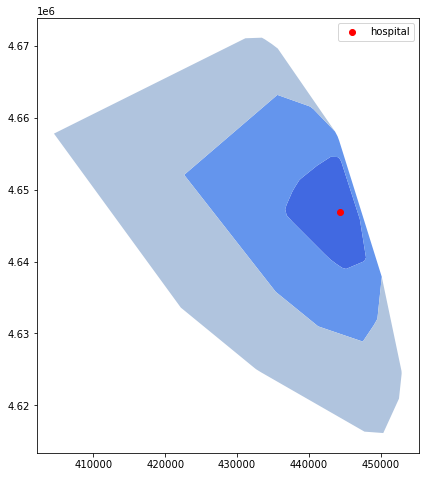

In [171]:
# Create point geometries for entire graph
# what is the pupose of the following two lines? Can this be deleted?
# for node, data in G.nodes(data=True):
#     data['geometry']=Point(data['x'], data['y'])

# which hospital to visualize? 
fighosp = 0

# Create catchment for hospital 0
poly = dijkstra_cca_polygons(Gt, hospitals['nearest_osm'][fighosp], distances)

# Reproject polygons
for i in range(len(poly)):
    poly[i].crs = { 'init' : 'epsg:4326'}
    poly[i] = poly[i].to_crs({'init':'epsg:32616'})

# Reproject hospitals 
# Possible to map from the hospitals data rather than creating hospital_subset?
hospital_subset = hospitals.iloc[[fighosp]].to_crs(epsg=32616)

fig, ax = plt.subplots(figsize=(12,8))

min_10 = poly[0].plot(ax=ax, color="royalblue", label="10 min drive")
min_20 = poly[1].plot(ax=ax, color="cornflowerblue", label="20 min drive")
min_30 = poly[2].plot(ax=ax, color="lightsteelblue", label="30 min drive")

hospital_subset.plot(ax=ax, color="red", legend=True, label = "hospital")

# Add legend
ax.legend()

### Calculate hospital catchment areas

In [184]:
%%time
if hospital_dropdown.value == "hospital_subset":
    catchments = measure_acc_par(hospitals.iloc[:4], pop_data, Gt, distances, weights, num_proc=processor_dropdown.value)
else:
    catchments = measure_acc_par(hospitals, pop_data, Gt, distances, weights, num_proc=processor_dropdown.value)

Calculating 66 hospital catchments...
completed number: 0 5 10 15 1 6 16 11 2 7 17 12 3 8 18 13 4 9 19 14 25 20 35 30 26 21 36 3127  22 37 32 28 23 38 33 29 24 39 40 34 45 41 55 50 46 42 51 56 47 43 57 52 48 44 58 53 49 59 60 54 65 61 62 63 64 CPU times: user 6.11 s, sys: 642 ms, total: 6.75 s
Wall time: 7min 57s


### Calculate accessibility

In [185]:
%%time
# what does this for loop do? Remove null results?
for j in range(len(catchments)):
    catchments[j] = catchments[j][catchments[j][resource_dropdown.value]!=float('inf')]
result=overlapping_function(grid_file, catchments, resource_dropdown.value, weights, num_proc=processor_dropdown.value)

CPU times: user 10.4 s, sys: 702 ms, total: 11.1 s
Wall time: 1min 57s


In [186]:
# add weight field to each catchment polygon
for i in range(len(weights)):
    catchments[i]['weight'] = weights[i]
# combine the three sets of catchment polygons into one geodataframe
geocatchments = pd.concat([catchments[0], catchments[1], catchments[2]])
geocatchments

,geometry,time,total_pop,icu_beds,vents,weight
0,"POLYGON ((445179.143 4638984.728, 444631.933 4...",10,649746.78,0.000055,0.000018,1.00
0,"POLYGON ((438522.380 4611688.522, 432500.229 4...",10,518276.42,0.000378,0.000123,1.00
0,"POLYGON ((444410.308 4649987.662, 443665.508 4...",10,353035.72,0.000252,0.000082,1.00
0,"POLYGON ((423893.472 4621571.092, 421747.249 4...",10,530716.34,0.000122,0.000040,1.00
0,"POLYGON ((443394.989 4617198.021, 443294.926 4...",10,549015.52,0.000120,0.000038,1.00
...,...,...,...,...,...,...
0,"POLYGON ((413304.564 4624675.782, 411438.057 4...",30,883626.18,0.000031,0.000010,0.22
0,"POLYGON ((423832.722 4623167.269, 412753.869 4...",30,631863.06,0.000071,0.000022,0.22
0,"POLYGON ((450149.221 4637875.751, 451863.333 4...",30,886772.14,0.000095,0.000030,0.22
0,"POLYGON ((412193.230 4628128.056, 411285.093 4...",30,800327.78,0.000076,0.000025,0.22


In [187]:
%%time

# if the value to be calculated is already in the hegaxon grid, delete it
# otherwise, the field name gets a suffix _1 in the overlay step
if resource_dropdown.value in list(grid_file.columns.values):
    grid_file = grid_file.drop(resource_dropdown.value, axis = 1)
    
# calculate hexagon 'target' areas
grid_file['area'] = grid_file.area
    
# Intersection overlay of hospital catchments and hexagon grid
print("Intersecting hospital catchments with hexagon grid...")
fragments = gpd.overlay(grid_file, geocatchments, how='intersection')

# Calculate percent coverage of the hexagon by the hospital catchment as
# fragment area / target(hexagon) area
fragments['percent'] = fragments.area / fragments['area']

# if using weighted aggregation... 
if weighted:
    print("Calculating area-weighted value...")
    # multiply the service/population ratio by the distance weight and the percent coverage
    fragments['value'] = fragments[resource_dropdown.value] * fragments['weight'] * fragments['percent']

# if using the 50% coverage rule for unweighted aggregation...
else:
    print("Calculating value for hexagons with >=50% overlap...")
    # filter for only the fragments with > 50% coverage by hospital catchment
    fragments = fragments[fragments['percent']>=0.5]
    # multiply the service/population ration by the distance weight
    fragments['value'] = fragments[resource_dropdown.value] * fragments['weight']

# select just the hexagon id and value from the fragments,
# group the fragments by the (hexagon) id,
# and sum the values
print("Summarizing results by hexagon id...")
sum_results = fragments[['id', 'value']].groupby(by = ['id']).sum()

# join the results to the hexagon grid_file based on hexagon id
print("Joining results to hexagons...")
result = pd.merge(grid_file, sum_results, how="left", on = "id")

# rename value column name to the resource name
result.rename(columns = {'value' : resource_dropdown.value}, inplace=True)

result

Intersecting hospital catchments with hexagon grid...
Calculating area-weighted value...
Summarizing results by hexagon id...
Joining results to hexagons...
CPU times: user 13.6 s, sys: 62.9 ms, total: 13.6 s
Wall time: 14.1 s


,left,top,right,bottom,id,area,geometry,icu_beds
0,440843.416087,4.638515e+06,441420.766356,4.638015e+06,4158,216506.350946,"POLYGON ((440843.416 4638265.403, 440987.754 4...",0.003815
1,440843.416087,4.638015e+06,441420.766356,4.637515e+06,4159,216506.350946,"POLYGON ((440843.416 4637765.403, 440987.754 4...",0.003814
2,440843.416087,4.639515e+06,441420.766356,4.639015e+06,4156,216506.350946,"POLYGON ((440843.416 4639265.403, 440987.754 4...",0.003923
3,440843.416087,4.639015e+06,441420.766356,4.638515e+06,4157,216506.350946,"POLYGON ((440843.416 4638765.403, 440987.754 4...",0.003856
4,440843.416087,4.640515e+06,441420.766356,4.640015e+06,4154,216506.350946,"POLYGON ((440843.416 4640265.403, 440987.754 4...",0.003974
...,...,...,...,...,...,...,...,...
3274,440843.416087,4.643015e+06,441420.766356,4.642515e+06,4149,216506.350946,"POLYGON ((440843.416 4642765.403, 440987.754 4...",0.003982
3275,440843.416087,4.644515e+06,441420.766356,4.644015e+06,4146,216506.350946,"POLYGON ((440843.416 4644265.403, 440987.754 4...",0.003909
3276,440843.416087,4.644015e+06,441420.766356,4.643515e+06,4147,216506.350946,"POLYGON ((440843.416 4643765.403, 440987.754 4...",0.003937
3277,440843.416087,4.645515e+06,441420.766356,4.645015e+06,4144,216506.350946,"POLYGON ((440843.416 4645265.403, 440987.754 4...",0.003489


In [188]:
%%time
result = normalization(result, resource_dropdown.value)

CPU times: user 4.86 ms, sys: 973 µs, total: 5.83 ms
Wall time: 22.6 ms


In [189]:
result.head()

,left,top,right,bottom,id,area,geometry,icu_beds,icu_bedsorig
0,440843.416087,4.638515e+06,441420.766356,4.638015e+06,4158,216506.350946,"POLYGON ((440843.416 4638265.403, 440987.754 4...",0.938212,0.003815
1,440843.416087,4.638015e+06,441420.766356,4.637515e+06,4159,216506.350946,"POLYGON ((440843.416 4637765.403, 440987.754 4...",0.937935,0.003814
2,440843.416087,4.639515e+06,441420.766356,4.639015e+06,4156,216506.350946,"POLYGON ((440843.416 4639265.403, 440987.754 4...",0.965577,0.003923
3,440843.416087,4.639015e+06,441420.766356,4.638515e+06,4157,216506.350946,"POLYGON ((440843.416 4638765.403, 440987.754 4...",0.948503,0.003856
4,440843.416087,4.640515e+06,441420.766356,4.640015e+06,4154,216506.350946,"POLYGON ((440843.416 4640265.403, 440987.754 4...",0.978445,0.003974


### Save results

In [190]:
# Save output to geopackage -- will name the layer according the dropdown parameters
if weighted:
    resultfile = 'data/derived/public/results_areaweighted.gpkg'
elif oxSpeed:
    resultfile = 'data/derived/public/results_oxspeed.gpkg'
else:
    resultfile = 'data/derived/public/results.gpkg'
layername = '{}_{}'.format(population_dropdown.value,resource_dropdown.value)

result[["id",resource_dropdown.value+'orig',resource_dropdown.value,"geometry"]].to_file(resultfile, 
                layer=layername, 
                driver='GPKG')

## Spatial accessibility map

CPU times: user 2.22 s, sys: 51.4 ms, total: 2.27 s
Wall time: 3.29 s


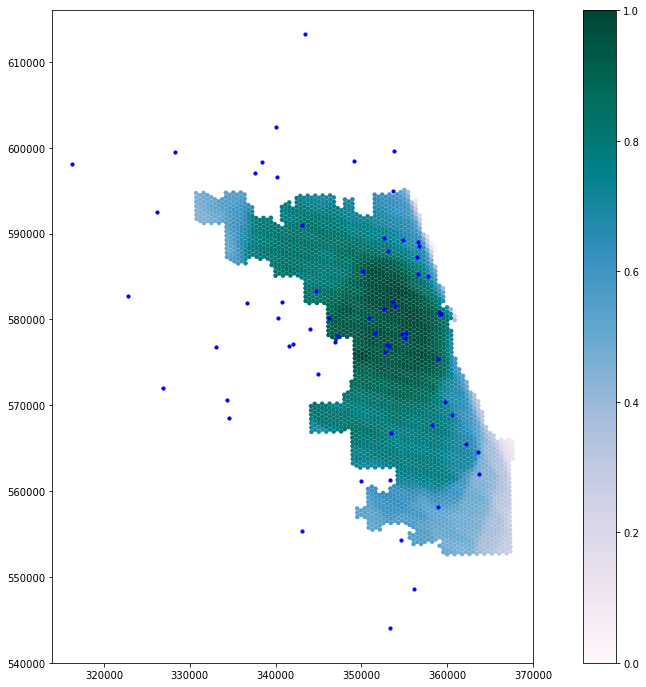

In [191]:
%%time
hospitals = hospitals.to_crs({'init': 'epsg:26971'})
result = result.to_crs({'init': 'epsg:26971'})
output_map(result, pop_data, hospitals, resource_dropdown.value)

### References

Luo, W., & Qi, Y. (2009). An enhanced two-step floating catchment area (E2SFCA) method for measuring spatial accessibility to primary care physicians. Health & place, 15(4), 1100-1107.